In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.random as jrand
from abm_event import sample_event, conditional_sample
from abm_ll import city_ll, eval_ds

import pickle
from stat_utils import CityParams, EventOutcome, GeneralParams
params = GeneralParams(propensity=1e-6, walk_radius=65, arm_bias=0.1, arm_weight=1.0, atrisk_gathering_rate=1e-6)
with open('data/county_data.pkl', 'rb') as f:
    city_data = pickle.load(f)
def hasna(p):
    return any(np.isnan(x) for x in p)
city_data = {k: v for k, v in city_data.items() if not hasna(v['params'])}
city_data_f = [c for c in city_data.values() if c['events']]
city_data_base = [c for c in city_data.values() if not c['events']]
city_base_ind = np.arange(len(city_data_base))
np.random.seed(1)
np.random.shuffle(city_base_ind)
subsampled_city_data_base = np.array(city_data_base)[city_base_ind[:400]]
subsampled_city_data = np.concatenate([city_data_f, subsampled_city_data_base])
base_weight = len(city_data_base) / 400
subsample_weights = np.array([1+base_weight*(len(c['events']) == 0) for c in subsampled_city_data])

[EventOutcome(date='2/28/22', fatalities=4, injured=0, total_victims=4)]
-12.043821962660974 -10.069914692644554 -1.9739072700164204
-11.668104980938198 -9.305003806888982 -2.3631011740492163
-12.003344496089762 -8.952385971038613 -3.050958525051149
-11.085889301632394 -9.205328652492112 -1.880560649140282
-10.637330727960633 -9.095901337235215 -1.5414293907254173


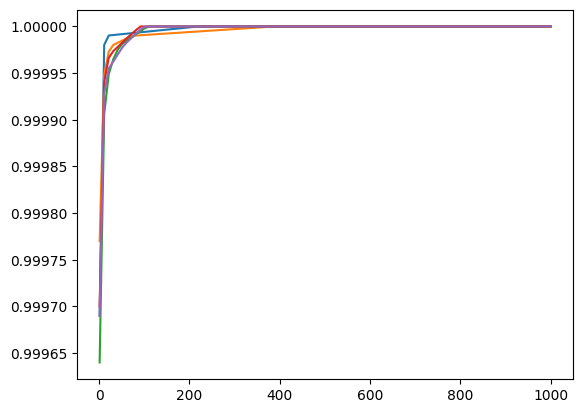

In [54]:
c = subsampled_city_data[10]
params = GeneralParams(propensity=1e-8, walk_radius=40, arm_bias=1.0, arm_weight=1.0, atrisk_gathering_rate=1e-8)
# result = eval_ds(subsampled_city_data, params, 50, jrand.PRNGKey(0), num_samples=int(1e5))
from stat_utils import grenander_pdf
c_params = c['params']
c_events = c['events']
print(c_events)
for i in range(5):
    event_sim = conditional_sample(c_params, params, jrand.PRNGKey(i), num_samples=int(1e5))
    city_distr = grenander_pdf(event_sim+1)
    ll, pll, eventll = city_ll(c_params, c_events, params, 50, city_distr)
    print(ll, pll, eventll)
    x = np.linspace(1, 1000, 100)
    plt.plot(x, city_distr.cdf(x))

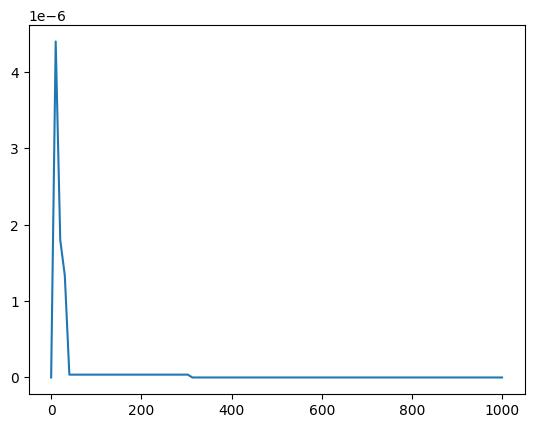

In [43]:
subkey = jrand.PRNGKey(0)
samples = jnp.max(jrand.weibull_min(subkey, 10, 0.4, (int(1e6), 10)), axis=1)
samples = jrand.uniform(subkey, samples.shape) * samples

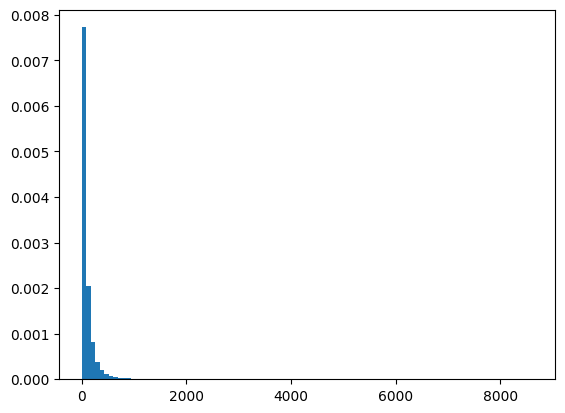

In [44]:
plt.hist(np.array(samples), bins=100, density=True)
plt.show()


In [32]:
params = GeneralParams(propensity=1e-6, walk_radius=40, arm_bias=1.0, arm_weight=1.0, atrisk_gathering_rate=1e-8)
# result = eval_ds(subsampled_city_data, params, 50, jrand.PRNGKey(0), num_samples=int(1e5))
from stat_utils import grenander_pdf
ll_data = []
rng_key = jrand.PRNGKey(0)
rng_keys = jrand.split(rng_key, len(subsampled_city_data))
for i, c in enumerate(subsampled_city_data):
    # rng_key, subkey = jrand.split(rng_key, 2)
    c_params = c['params']
    c_events = c['events']
    event_sim = conditional_sample(c_params, params, rng_keys[i], num_samples=int(1e5))
    city_distr = grenander_pdf(event_sim+1)
    ll, pll, eventll = city_ll(c_params, c_events, params, 50, city_distr)
    ll_data.append([ll, pll, eventll])

NameError: name 'plt' is not defined

In [30]:
c = subsampled_city_data[114]
c_params = c['params']
c_events = c['events']
event_sim = conditional_sample(c_params, params, subkey, num_samples=int(1e5))
city_distr = grenander_pdf(event_sim+1)
ll, pll, eventll = city_ll(c_params, c_events, params, 50, city_distr)


In [31]:
ll, pll, eventll

(-10.79409174393204, -9.57911438413021, -1.2149773598018285)

In [24]:
(ll_data > 0).nonzero()
ll_data[[53, 114], :]

array([[-14.49530539, -14.92173277,   0.42642737],
       [-10.7081688 , -11.48755873,   0.77938993]])

In [19]:
ll_data = np.array(ll_data)
ll_data.min(), ll_data.max(), ll_data.mean(), ll_data.std()

/home/andrew/anaconda3/envs/baybm/lib/python3.10/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


(-inf, 0.7793899252323673, -inf, nan)

In [14]:
event_sim = conditional_sample(c_params, params, subkey, num_samples=int(1e5))
city_distr = grenander_pdf(event_sim+1)
ll, pll, eventll = city_ll(c_params, c_events, params, 50, city_distr)

In [13]:
from abm_ll import poisson_ll
poisson_ll(0, 0)

0

In [20]:
subkey = jrand.PRNGKey(10)
event_sim = conditional_sample(c_params, params, subkey, num_samples=int(1e5))
city_distr = grenander_pdf(event_sim+1)

In [ ]:
fatalities = np.array([e.fatalities for e in c_events])[0]
city_distr.pdf(fatalities)
=

/tmp/ipykernel_1199123/561317443.py:4: RuntimeWarning: divide by zero encountered in log
  np.log(0) - np.log(0)
/tmp/ipykernel_1199123/561317443.py:4: RuntimeWarning: invalid value encountered in scalar subtract
  np.log(0) - np.log(0)


nan

In [ ]:
ll, pll, eventll = city_ll(c_params, c_events, params, 50, city_distr)


In [8]:
np.unique(event_sim)

array([0.        , 0.06300218], dtype=float32)